In [1]:
import numpy as np
from matplotlib.cm import get_cmap
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import multiprocessing as mp
from tqdm import tqdm
from joblib import Parallel, delayed
from scipy import stats
import os
from stoch_sim_model import *
from optimize_nets import *
import seaborn as sns

plt.style.use('custom.mplstyle')
%config InlineBackend.figure_format = 'retina'

In [2]:
# define global parameters
sim_kind = 'agent'
infection_type = 'sec'
reg_model = ''
runs = '-400-'
reg = np.array([2.0, 2.0, 1.0, 1.0, 2.0, 2.0])
reg_logic = np.array([1,1,1])

comment = 'no-cell-var'
pnts = 100
virs = vir_prop[1:]

In [3]:
# run simulations for extreme scenarios
extreme_virs = np.array([[1.5*d_S, K_IE], [10*d_S, K_IE], [d_S, 10*K_IE], [10*d_S, 10*K_IE]])
print(extreme_virs)
run(regs = reg, reg_logs = reg_logic, virus_sample = extreme_virs)

[[7.5e-02 1.0e+04]
 [5.0e-01 1.0e+04]
 [5.0e-02 1.0e+05]
 [5.0e-01 1.0e+05]]
Running with regs = [1.0, 1.0, 0.0, 0.0, 1.0, 1.0]
Running with logic = [1, 1, 1]
Will save to 2-2-1-1-2-2-400-sec-1-1-1-no-cell-var.pkl.
Running simulation


/mmfs1/home/oukogu/infoimmune/stoch_sim_model.py:498: RuntimeWarning: divide by zero encountered in scalar divide
  b_unbind_t[j] = np.fmin((K_IE/delta + np.sum(N_m[i-1] + Na_m[i-1] + cMa_m[i] + Ein_m[i]) + p_tcr[j]*Ain[i])/(p_tcr[j]*char_times[1]*Ain[i]), 1/(dt*trans_steps[1])) # set fastest rate of unbinding events
/mmfs1/home/oukogu/infoimmune/stoch_sim_model.py:498: RuntimeWarning: divide by zero encountered in scalar divide
  b_unbind_t[j] = np.fmin((K_IE/delta + np.sum(N_m[i-1] + Na_m[i-1] + cMa_m[i] + Ein_m[i]) + p_tcr[j]*Ain[i])/(p_tcr[j]*char_times[1]*Ain[i]), 1/(dt*trans_steps[1])) # set fastest rate of unbinding events
/mmfs1/home/oukogu/infoimmune/stoch_sim_model.py:498: RuntimeWarning: divide by zero encountered in scalar divide
  b_unbind_t[j] = np.fmin((K_IE/delta + np.sum(N_m[i-1] + Na_m[i-1] + cMa_m[i] + Ein_m[i]) + p_tcr[j]*Ain[i])/(p_tcr[j]*char_times[1]*Ain[i]), 1/(dt*trans_steps[1])) # set fastest rate of unbinding events
/mmfs1/home/oukogu/infoimmune/stoch_sim_mod

Saving
Saved 2-2-1-1-2-2-400-sec-1-1-1-no-cell-var.pkl


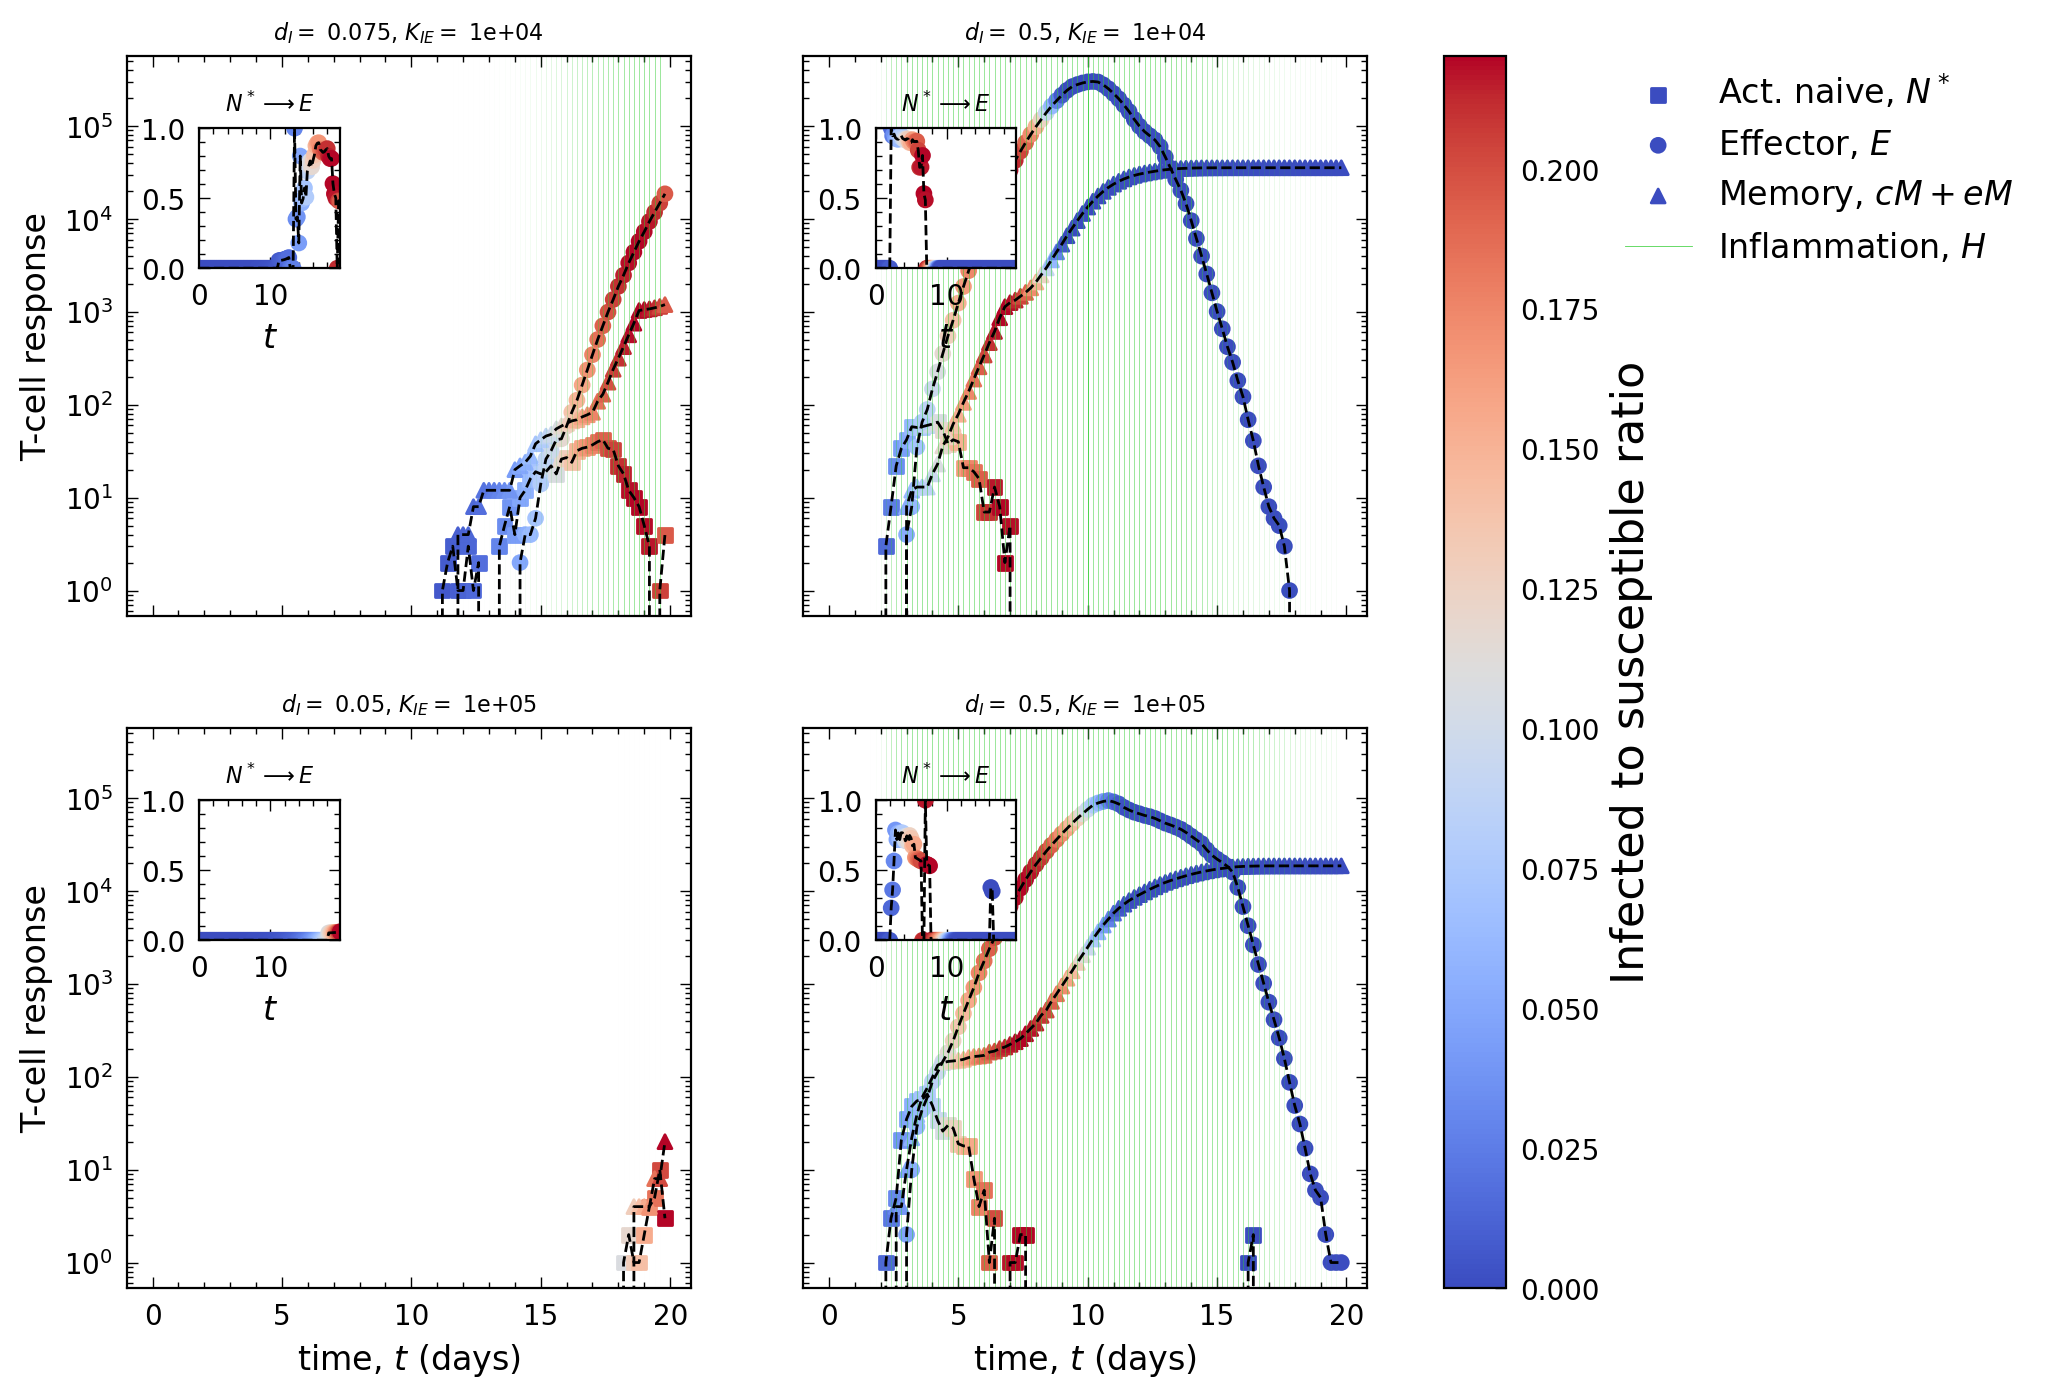

In [4]:
with open("/mmfs1/home/oukogu/infoimmune/2-2-1-1-2-2-400-sec-1-1-1-no-cell-var.pkl", 'rb') as f:   
    data_dict = pickle.load(f)

n = len(extreme_virs)
dyn = data_dict["cell_time_series"]
ts = data_dict["time"]
p_diff = data_dict["prim_diff_bias"]
keep = [i*int(sim_steps/pnts) for i in np.arange(0,pnts)]
rows = 2

fig, axs = plt.subplots(int(n/2), int(n/2), figsize=(2*n + 2, 2*n), sharex=True, sharey=True)

for l, (d_I, K_IE) in enumerate(extreme_virs):
    dyn_data = dyn[l][keep]
    p_diff_data = p_diff[l][keep]
    time = np.linspace(0, sim_duration, int(sim_steps) + 1)[keep]
    
    pS, sS, pI, sI, Ain, pN, pE, sE, pcM, scM, peM, seM, pH, sH, pI_d_I, sI_d_I, pI_d_S, sI_d_S = dyn_data[:,0], dyn_data[:,-10], dyn_data[:,1], dyn_data[:,-9], dyn_data[:,-8], dyn_data[:,3], dyn_data[:, 4], dyn_data[:,-6], dyn_data[:,5], dyn_data[:, -5], dyn_data[:,6], dyn_data[:,-4], dyn_data[:,7], dyn_data[:,-3], dyn_data[:,8], dyn_data[:,-2], dyn_data[:,9],dyn_data[:,-1]

    x,y = int(np.floor(rows*l/n)), l % int(np.ceil((n/rows)))

    [axs[x,y].axvline(x=time[k], linestyle='-', linewidth=0.2, color='limegreen', alpha=pH[k]) for k in np.arange(0, len(pH)-1)]
    axs[x,y].plot(time, pN, 'k--')
    im = axs[x,y].scatter(time, pN, marker = 's', c = pI/S_0, cmap='coolwarm', label = r'Act. naive, $N^*$')
    
    axs[x,y].plot(time, pE, 'k--')
    axs[x,y].scatter(time, pE, marker = 'o', c = pI/S_0, cmap='coolwarm', label = r'Effector, $E$')

    axs[x,y].plot(time, pcM + peM, 'k--')
    axs[x,y].scatter(time, pcM + peM, marker = '^', c = pI/S_0, cmap='coolwarm', label = r'Memory, $cM + eM$')

    axs[x,y].set_title(r"$d_I =$ "+str(np.round(d_I,3))+r", $K_{IE} =$ "+str(format(K_IE,'.0e')), fontsize = 8)

    # # inset plot: these are in unitless percentages of the figure size. (0,0 is bottom left)
    axins = inset_axes(axs[x,y], width="25%", height="25%", loc=2, borderpad = 2.6)
    axins.plot(time, p_diff_data[:,0], 'k--')
    axins.scatter(time, p_diff_data[:,0], marker = 'o', c = pI/S_0, cmap='coolwarm') #, label = r'Bias$_t(N^* \longrightarrow E)$')
    axins.set(xlabel=r'$t$')
    axins.set_title(r'$N^* \longrightarrow E$', fontsize = 8)
    axins.axis([0.0, time[-1], 0.0, 1.0])
       
    if y == 0:
        axs[x,0].set(ylabel = "T-cell response")
        # axs[0,0].legend(loc='upper right')

    if x == int(n/rows)-1:
        axs[x,y].set(xlabel= r"time, $t$ (days)")

axs[0,1].axvline(x=time[np.argmax(pH)], linestyle='-', linewidth=0.3, color='limegreen', alpha=pH[np.argmax(pH)], label =r"Inflammation, $H$")
axs[0,1].legend(loc='center right', bbox_to_anchor=(2.2, 0.8), fontsize = 12)

cb = fig.colorbar(im, ax=axs, orientation='vertical')
cb.set_label("Infected to susceptible ratio", fontsize = 16)
    
for i, ax in enumerate(axs.flat):
    ax.semilogy()

# for ax in axs.flat:
#     ax.label_outer()
        
plt.savefig('_figs/dI_KIE_response_dynamics', dpi=300, bbox_inches='tight')

In [ ]:
# Plot trends for different networks based on signal correlation
d_mean = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/cell_time_series/mean/'
d_std = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/cell_time_series/std/'

n = len(virs)
fig, axs = plt.subplots(3, n, figsize=(8, 6), sharex=True)


for file_count, f in enumerate(tqdm(os.listdir(d_mean))):
    if '-100-' not in f or infection_type not in f:
        continue
    dyn_net = np.load(os.path.join(d_mean, f))
    #dyn_std = np.load(os.path.join(d_std, f))
    keep = [i*int(sim_steps/pnts) for i in np.arange(0,pnts)]
    
    for l, (d_I, K_IE) in enumerate(virs):
        dyn_mean = dyn_net[l+1][keep]
    
        pS, sS, pI, sI, Ain, N, pE, sE, pcM, scM, peM, seM, pH, sH, pI_d_I, sI_d_I, pI_d_S, sI_d_S = dyn_mean[:,0], dyn_mean[:,-10], dyn_mean[:,1], dyn_mean[:,-9], dyn_mean[:,-8], dyn_mean[:,-7], dyn_mean[:, 4], dyn_mean[:,-6], dyn_mean[:,5], dyn_mean[:, -5], dyn_mean[:,6], dyn_mean[:,-4], dyn_mean[:,7], dyn_mean[:,-3], dyn_mean[:,8], dyn_mean[:,-2], dyn_mean[:,9], dyn_mean[:,-1]
    
        time = np.linspace(0, sim_duration, int(sim_steps) + 1)[keep]
        
    
        # axs[0,l].plot(time, pS, color='grey', 
        #             label = r'Susceptible, $S_p$') #, norm=mpl.colors.LogNorm())
        axs[0,l].plot(time, pI, color='grey',
                    label = r'Infected, $I_p$', alpha = 0.01)
        axs[1,l].plot(time, pE, color='grey',
                    label = r'Effector, $E_p$', alpha = 0.01)
        axs[2,l].plot(time, pcM + peM, color='grey',
                    label = r'Memory, $cM_p+eM_p$', alpha = 0.01)
        # axs[4,l].plot(time, pH, color='grey',
        #             label = r'Inflammation, $H_p$')
        
        axs[0,l].set_title(r"$d_I =$ "+str(np.round(d_I,3))+r", $K_{I,E} =$ "+str(np.round(K_IE,0)), fontsize = 8)
        
        # if file_count == 0:
        #     axs[0,0].legend(fontsize = 8)
        #     axs[1,0].legend(fontsize = 8)
        #     axs[2,0].legend(fontsize = 8)
        #     axs[3,0].legend(fontsize = 8)
        #     axs[4,0].legend(fontsize = 8)

y_labels = [r'Infected, $I_p$',r'Effector, $E_p$',r'Memory, $cM_p+eM_p$']
for i, ax in enumerate(axs.flat):
    ax.set(xlabel= r"time, $t$ (days)")
    ax.set_yscale('log')
    if i % 4 == 0:
        ax.set(ylabel= y_labels[int(i/4)])

for ax in axs.flat:
    ax.label_outer()
        
#plt.savefig('_figs/dI_KIE_response_dynamics', dpi=300, bbox_inches='tight')

In [ ]:
# Plot trends for different networks based on signal correlation
d_mean = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/diff_bias/mean/'
d_std = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/diff_bias/std/'

n = len(vir_prop)
fig, axs = plt.subplots(3, n, figsize=(10, 6), sharex=True, sharey = True)

for file_count, f in enumerate(tqdm(os.listdir(d_mean))):
    if '-100-' not in f or infection_type not in f:
        continue
    diff_bias_net = np.load(os.path.join(d_mean, f))
    keep = [i*int(sim_steps/pnts) for i in np.arange(0,pnts)]
    
    for l, (d_I, K_IE) in enumerate(virs):
        diff_bias = diff_bias_net[l][keep]
        time = np.linspace(0, sim_duration, int(sim_steps) + 1)[keep]
    
        axs[0,l].plot(time, diff_bias[:,0], color='grey', 
                    label = r'Bias$_t(N^* \longrightarrow E)$', alpha = 0.01)
        axs[1,l].plot(time, diff_bias[:,1], color='grey',
                    label = r'Bias$_t(E_{in} \longrightarrow eM)$', alpha = 0.01)
        axs[2,l].plot(time, diff_bias[:,2], color='grey',
                    label = r'Bias$_t(E_{out} \longrightarrow eM)$', alpha = 0.01)
        
        axs[0,l].set_title(r"$d_I =$ "+str(np.round(d_I,3))+r", $K_{I,E} =$ "+str(np.round(K_IE,0)), fontsize = 8)
        
        if file_count == 0:
            axs[0,0].legend(fontsize = 8)
            axs[1,0].legend(fontsize = 8)
            axs[2,0].legend(fontsize = 8)
    
for i, ax in enumerate(axs.flat):
    ax.set(xlabel= r"time, $t$ (days)")

for ax in axs.flat:
    ax.label_outer()
        
#plt.savefig('_figs/dI_KIE_response_dynamics', dpi=300, bbox_inches='tight')

In [ ]:
# Plot trends for different networks based on signal correlation
n = len(vir_prop[1:])
n_d_I, n_K_IE = len(np.unique(virs[:,1])), len(np.unique(virs[:,0]))
fig, axs = plt.subplots(n_K_IE, n_d_I, figsize=(8, 6), sharex=True, sharey=True)


for file_count, f in enumerate(tqdm(os.listdir(d_mean)[0:5])):
    if '-100-' not in f or infection_type not in f:
        continue
    dyn_net = np.load(os.path.join(d_mean, f))
    #dyn_std = np.load(os.path.join(d_std, f))
    
    for l, (d_I, K_IE) in enumerate(virs):
        dyn_mean = dyn_net[l+1]
        x,y = l % n_d_I, int(np.floor(l/n_K_IE))
    
        pS, sS, pI, sI, Ain, N, pE, sE, pcM, scM, peM, seM, pH, sH, pI_d_I, sI_d_I, pI_d_S, sI_d_S = dyn_mean[:,0], dyn_mean[:,-10], dyn_mean[:,1], dyn_mean[:,-9], dyn_mean[:,-8], dyn_mean[:,-7], dyn_mean[:, 4], dyn_mean[:,-6], dyn_mean[:,5], dyn_mean[:, -5], dyn_mean[:,6], dyn_mean[:,-4], dyn_mean[:,7], dyn_mean[:,-3], dyn_mean[:,8], dyn_mean[:,-2], dyn_mean[:,9], dyn_mean[:,-1]
        
        keep = [i*int(len(pE)/pnts) for i in np.arange(0,pnts)]
        psus = pS[keep]
        naive = N[keep]
        peff = pE[keep]
        pmem = (pcM+peM)[keep]
        p_load = pI[keep]/np.max(pI)
        time = np.linspace(0, sim_duration, int(sim_steps) + 1)[keep]
    
        im = axs[x,y].scatter(time, naive, marker ='s', c =p_load, cmap='coolwarm', 
                    label = r'Act. naive, $N^*$') #, norm=mpl.colors.LogNorm())
        axs[x,y].plot(time, naive, 'k--', alpha = 0.1)
        axs[x,y].plot(time, peff, 'k--', alpha = 0.1)
        axs[x,y].plot(time, pmem, 'k--', alpha = 0.1)
        axs[x,y].set_title(r"$d_I =$ "+str(np.round(d_I,3))+r", $K_{IE} =$ "+str(np.round(K_IE,0)), fontsize = 8)
        #axs[x,y].set_title("d_I = {}".format(np.round(d_I,3))+", K_IE = {}".format(K_IE), fontsize = 8)
        
        if x == 0 and y == 0 and file_count == 0:
            axs[x,y].legend(fontsize = 8)
    
for i, ax in enumerate(axs.flat):
    ax.set(xlabel= r"time, $t$ (days)",
           ylabel= 'cellular response')
    ax.set_yscale('log')

for ax in axs.flat:
    ax.label_outer()
    
cb = fig.colorbar(im, ax=axs, orientation='vertical')
cb.set_label(r"Infection progression, $\frac{I}{max(I_{0 \to t})}$")
        
#plt.savefig('_figs/dI_KIE_response_dynamics', dpi=300, bbox_inches='tight')